In [1]:
cd '/kaggle/input'

/kaggle/input


In [18]:
!apt-get update && apt-get install -y tree

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]           
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,599 kB]
Get:10 https://cli.github.com/packages stable/main amd64 Packages [356 B]      
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InReleas

In [25]:
cd '/kaggle/input/datasets/nagahuy'

/kaggle/input/datasets/nagahuy


In [27]:
!tree -L 3

.
└── tdtt-ver1
    ├── images
    │   ├── ChIJ22p6x2AvdTERFDZPouHGoMs
    │   ├── ChIJ2bO2S6UvdTER2gFlY1s-IJU
    │   ├── ChIJ2xW0W5EvdTERDwMPy7z7n0k
    │   ├── ChIJ3yg2LEkvdTERL8-WeUdBSFU
    │   ├── ChIJ67SU4vMudTERyb8_WbHBIiU
    │   ├── ChIJ6cL6ZtkvdTERFI5pV9DaJjQ
    │   ├── ChIJ9XAX8oAvdTER1ub-ybAdDbk
    │   ├── ChIJa50yEW8ndTEREAK7y57f978
    │   ├── ChIJcQv9BwAvdTERd0YnfoeH0gA
    │   ├── ChIJeX1s4_IvdTERKZRLuMufrUQ
    │   ├── ChIJf5dULuwldTERhbtf7fImTZo
    │   ├── ChIJ-fCCywwndTERBy8ZHAa9B5k
    │   ├── ChIJFx7EFQAndTER_QcnargOn1Y
    │   ├── ChIJgRwlQ5MvdTERqQ_32WTjau8
    │   ├── ChIJgWfui4gndTERAY0pIZ6B8CE
    │   ├── ChIJI5ehazgldTERH5FH6JbUJcI
    │   ├── ChIJIUO8zYkldTER6zQ-eZjGaSA
    │   ├── ChIJjyx4Oe8vdTERzPNy7iVETQY
    │   ├── ChIJk8qFZOUldTERcbwPHDZK9n4
    │   ├── ChIJk8X2Fy0vdTERJNAx-4NCts0
    │   ├── ChIJmSbykKsvdTERHnCl6ou9HiI
    │   ├── ChIJmTwzucwldTERcqxLB6bYWNo
    │   ├── ChIJMzp1gSUvdTER-IanzsYU1Sc
    │   ├── ChIJnbKCt0UpdTERT3CIorMTWzw
    │   ├

In [5]:
import os
import json
from collections import defaultdict
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

ROOT = '/kaggle/input/datasets/nagahuy/tdtt-ver1'

IMAGES_DIR = os.path.join(ROOT, "images")
METADATA_DIR = os.path.join(ROOT, "metadata")
NOISE_DIR = os.path.join(ROOT, "noises")

In [6]:
for root, dirs, files in os.walk(ROOT):
    level = root.replace(ROOT, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    
    subindent = ' ' * 2 * (level + 1)
    for f in files[:5]:  # limit file preview
        print(f"{subindent}{f}")

tdtt-ver1/
  metadata/
    raw_reviews.json
    places.json
    clean_reviews.json
    images_metadata.json
  noises/
    bill/
      006.jpg
      002.jpg
      010.jpg
      001.jpg
      007.jpg
    text/
      ChIJjyx4Oe8vdTERzPNy7iVETQY_004.png
      ChIJWX-lRIkvdTERNoQyuLtbbAc_004.jpg
      ChIJq8lL5x4ndTERaR-1dV_Gqf0_002.jpg
      ChIJy-vbI6EldTERVONPShP8M9c_004.jpg
      ChIJgRwlQ5MvdTERqQ_32WTjau8_004.png
    food/
      ChIJWX-lRIkvdTERNoQyuLtbbAc_013.jpg
      ChIJgRwlQ5MvdTERqQ_32WTjau8_005.jpg
      ChIJXeAstn8mdTERTWy8UrjzSI8_005.jpg
      ChIJ2xW0W5EvdTERDwMPy7z7n0k_013.jpg
      ChIJ67SU4vMudTERyb8_WbHBIiU_012.jpg
  images/
    ChIJf5dULuwldTERhbtf7fImTZo/
      ChIJf5dULuwldTERhbtf7fImTZo_012.jpg
      ChIJf5dULuwldTERhbtf7fImTZo_005.jpg
      ChIJf5dULuwldTERhbtf7fImTZo_014.jpg
      ChIJf5dULuwldTERhbtf7fImTZo_006.jpg
      ChIJf5dULuwldTERhbtf7fImTZo_009.jpg
    ChIJgWfui4gndTERAY0pIZ6B8CE/
      ChIJgWfui4gndTERAY0pIZ6B8CE_009.jpg
      ChIJgWfui4gndTERAY0pIZ6B8CE_

# 1) Visualize an image with specified path

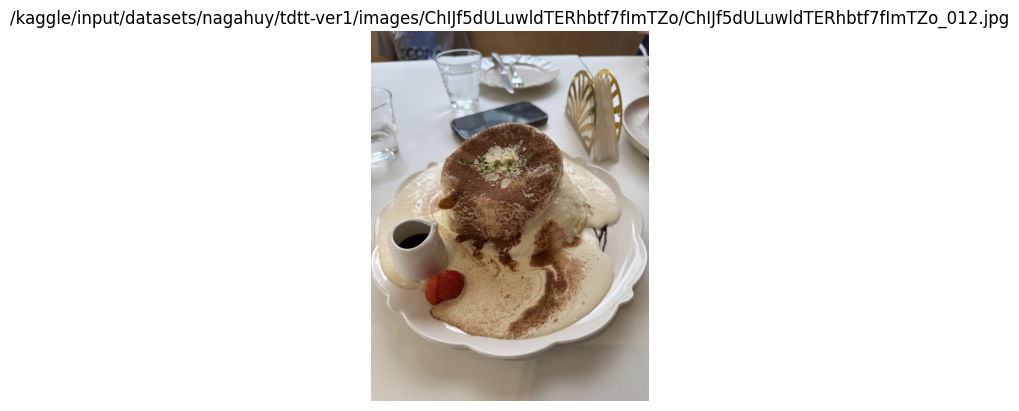

In [7]:
def show_image(img_path):
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(img_path)
    plt.show()

# Example: pick first image from first place
place_ids = os.listdir(IMAGES_DIR)
sample_place = place_ids[0]

sample_images = os.listdir(os.path.join(IMAGES_DIR, sample_place))
sample_img_path = os.path.join(IMAGES_DIR, sample_place, sample_images[0])

show_image(sample_img_path)

In [8]:
total_images = 0

for place_id in os.listdir(IMAGES_DIR):
    place_path = os.path.join(IMAGES_DIR, place_id)
    if os.path.isdir(place_path):
        total_images += len(os.listdir(place_path))

print("Total images:", total_images)

Total images: 539


In [9]:
place_image_counts = {}

for place_id in os.listdir(IMAGES_DIR):
    place_path = os.path.join(IMAGES_DIR, place_id)
    if os.path.isdir(place_path):
        place_image_counts[place_id] = len(os.listdir(place_path))

df_counts = pd.DataFrame(list(place_image_counts.items()), columns=["place_id", "num_images"])
df_counts.sort_values("num_images", ascending=False).head()

,place_id,num_images
0,ChIJf5dULuwldTERhbtf7fImTZo,15
2,ChIJ3yg2LEkvdTERL8-WeUdBSFU,15
7,ChIJa50yEW8ndTEREAK7y57f978,15
40,ChIJNSgishMvdTER-EzR7-2ZYnk,15
28,ChIJWX-lRIkvdTERNoQyuLtbbAc,15


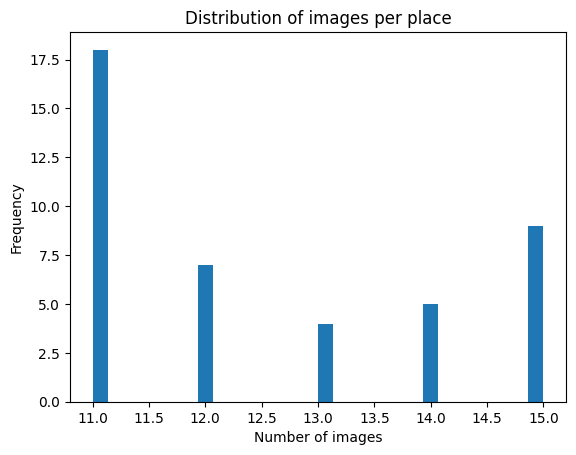

In [10]:
plt.hist(df_counts["num_images"], bins=30)
plt.title("Distribution of images per place")
plt.xlabel("Number of images")
plt.ylabel("Frequency")
plt.show()

In [11]:
image_sizes = []

for place_id in tqdm(os.listdir(IMAGES_DIR)):
    place_path = os.path.join(IMAGES_DIR, place_id)
    
    if not os.path.isdir(place_path):
        continue
        
    for img_name in os.listdir(place_path):
        img_path = os.path.join(place_path, img_name)
        
        try:
            img = Image.open(img_path)
            image_sizes.append(img.size)  # (width, height)
        except:
            continue

df_sizes = pd.DataFrame(image_sizes, columns=["width", "height"])
df_sizes.head()

100%|██████████| 43/43 [00:04<00:00,  9.95it/s]


,width,height
0,1200,1600
1,1600,1200
2,1200,1600
3,1600,1061
4,1600,1200


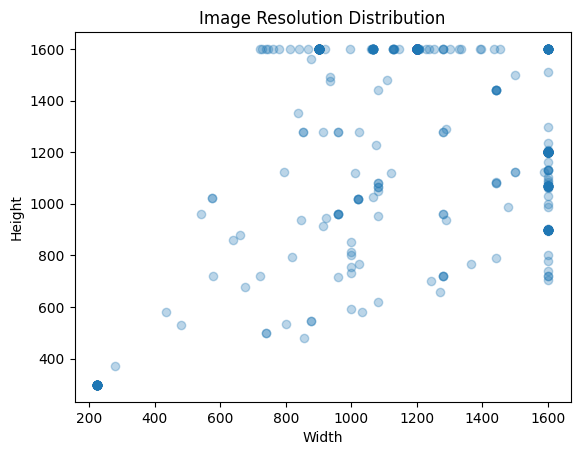

In [12]:
plt.scatter(df_sizes["width"], df_sizes["height"], alpha=0.3)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Resolution Distribution")
plt.show()

In [13]:
noise_stats = {}

for category in os.listdir(NOISE_DIR):
    cat_path = os.path.join(NOISE_DIR, category)
    
    if os.path.isdir(cat_path):
        noise_stats[category] = len(os.listdir(cat_path))

pd.DataFrame(list(noise_stats.items()), columns=["category", "count"])

,category,count
0,bill,10
1,text,17
2,food,14


In [14]:
def load_json(filename):
    path = os.path.join(METADATA_DIR, filename)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

places = load_json("places.json")
clean_reviews = load_json("clean_reviews.json")
raw_reviews = load_json("raw_reviews.json")
images_metadata = load_json("images_metadata.json")

print("Places:", len(places))
print("Clean reviews:", len(clean_reviews))
print("Raw reviews:", len(raw_reviews))
print("Images metadata:", len(images_metadata))

Places: 43
Clean reviews: 2580
Raw reviews: 2580
Images metadata: 539


In [15]:
df_places = pd.DataFrame(places)
df_reviews = pd.DataFrame(clean_reviews)
df_images_meta = pd.DataFrame(images_metadata)

df_places.head()

,lat,lng,city,name,source,address,district,place_id,avg_rating,total_reviews
0,10.854376,106.768466,Hồ Chí Minh,Tiệm bánh KICA,google_maps,"31 Tô Vĩnh Diện, Linh Chiểu",Thủ Đức,ChIJ-fCCywwndTERBy8ZHAa9B5k,3.7,1017
1,10.728098,106.706918,Hồ Chí Minh,Dolphy Café Mỹ Toàn,google_maps,"1441 Đường Nguyễn Văn Linh, Khu đô thị Phú Mỹ ...",Tân Hưng,ChIJ22p6x2AvdTERFDZPouHGoMs,4.7,415
2,10.735535,106.689315,Hồ Chí Minh,The Coffee House - Trung Sơn,google_maps,114 Đ. số 9A,Bình Hưng,ChIJ2bO2S6UvdTER2gFlY1s-IJU,4.3,1789
3,10.729430,106.706622,Hồ Chí Minh,Tuyet Hoa - Seol Hwa Bing Su,google_maps,"Sky Garden 1, Đ. Phạm Văn Nghị, Khu đô thị Phú...",Quận 7,ChIJ2xW0W5EvdTERDwMPy7z7n0k,4.4,734
4,10.772020,106.694101,Hồ Chí Minh,SOLOBOX Restaurant,google_maps,252 Lý Tự Trọng,Bến Thành,ChIJ3yg2LEkvdTERL8-WeUdBSFU,4.8,1551


In [16]:
# Check place_id consistency giữa images và metadata
image_place_ids = set(os.listdir(IMAGES_DIR))
metadata_place_ids = set(df_places["place_id"])

print("Missing in metadata:", image_place_ids - metadata_place_ids)
print("Missing in images:", metadata_place_ids - image_place_ids)

Missing in metadata: set()
Missing in images: set()


In [17]:
df_images_meta.sample(5)

,image_id,place_id,file_path,tags
184,image_d3f7edf1b323fa7d72f657b3b150965c,ChIJNVT4dVondTER-sL6PUoLOqE,images/ChIJNVT4dVondTER-sL6PUoLOqE/ChIJNVT4dVo...,[]
404,image_7b2e052a2f7f78a4ddd188e75c76819c,ChIJgWfui4gndTERAY0pIZ6B8CE,images/ChIJgWfui4gndTERAY0pIZ6B8CE/ChIJgWfui4g...,[]
151,image_510d73055e314ce9a8215c815ecd3a16,ChIJMzp1gSUvdTER-IanzsYU1Sc,images/ChIJMzp1gSUvdTER-IanzsYU1Sc/ChIJMzp1gSU...,[]
54,image_29ef9f90705b48d694da84e358e593c1,ChIJ3yg2LEkvdTERL8-WeUdBSFU,images/ChIJ3yg2LEkvdTERL8-WeUdBSFU/ChIJ3yg2LEk...,[]
401,image_3d1ce06f6078a0d2585b1aee0cef358f,ChIJgWfui4gndTERAY0pIZ6B8CE,images/ChIJgWfui4gndTERAY0pIZ6B8CE/ChIJgWfui4g...,[]


In [18]:
print("Avg images per place:", df_counts["num_images"].mean())
print("Min images:", df_counts["num_images"].min())
print("Max images:", df_counts["num_images"].max())

Avg images per place: 12.534883720930232
Min images: 11
Max images: 15


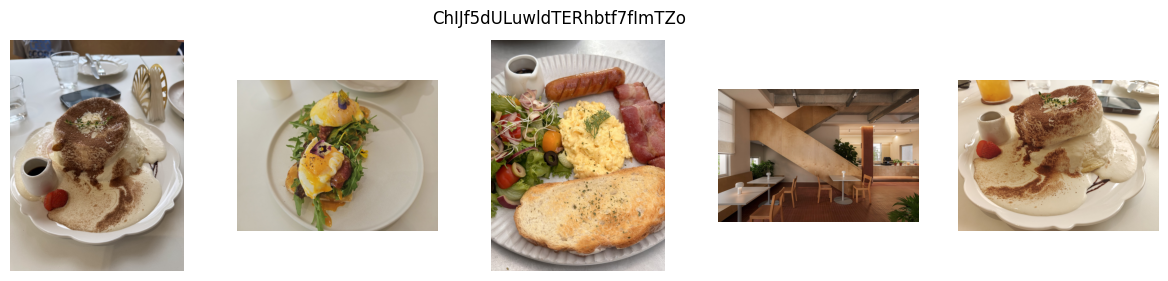

In [19]:
def show_place_images(place_id, n=5):
    place_path = os.path.join(IMAGES_DIR, place_id)
    imgs = os.listdir(place_path)[:n]
    
    plt.figure(figsize=(15, 3))
    
    for i, img_name in enumerate(imgs):
        img_path = os.path.join(place_path, img_name)
        img = Image.open(img_path)
        
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(place_id)
    plt.show()

show_place_images(sample_place)

# ViT pipeline

In [1]:
import os
import json
import numpy as np
import torch
from PIL import Image
from tqdm import tqdm
from transformers import AutoImageProcessor, AutoModel

ROOT = '/kaggle/input/datasets/nagahuy/tdtt-ver1'

IMAGES_DIR = os.path.join(ROOT, "images")
NOISE_DIR = os.path.join(ROOT, "noises")
METADATA_DIR = os.path.join(ROOT, "metadata")

SAVE_DIR = "/kaggle/working/embeddings"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

Using device: cuda


In [3]:
def load_json(name):
    with open(os.path.join(METADATA_DIR, name), "r", encoding="utf-8") as f:
        return json.load(f)

places = load_json("places.json")

# map place_id -> metadata (để inference dùng)
place_map = {p["place_id"]: p for p in places}

print("Loaded places:", len(place_map))

Loaded places: 43


In [4]:
MODEL_NAME = "google/vit-base-patch16-224"

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

model.to(DEVICE)
model.eval()

print("Model loaded")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded


In [5]:
def embed_images_batch(image_paths):
    images = []
    valid_paths = []

    for p in image_paths:
        try:
            img = Image.open(p).convert("RGB")
            images.append(img)
            valid_paths.append(p)
        except:
            continue

    inputs = processor(images=images, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)
        embeddings = outputs.last_hidden_state[:, 0]  # CLS token

    embeddings = embeddings.cpu().numpy()

    # normalize
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    embeddings = embeddings / norms

    return embeddings, valid_paths

In [6]:
noise_embeddings = []
noise_index = []

print("Encoding noise images...")

for category in os.listdir(NOISE_DIR):
    cat_path = os.path.join(NOISE_DIR, category)
    
    if not os.path.isdir(cat_path):
        continue

    image_paths = [
        os.path.join(cat_path, f)
        for f in os.listdir(cat_path)
    ]

    batch_size = 32
    
    for i in tqdm(range(0, len(image_paths), batch_size)):
        batch = image_paths[i:i+batch_size]
        emb, valid = embed_images_batch(batch)

        for j, path in enumerate(valid):
            idx = len(noise_embeddings)
            noise_embeddings.append(emb[j])

            noise_index.append({
                "idx": idx,
                "category": category,
                "file_path": path
            })

noise_embeddings = np.array(noise_embeddings)

np.save(os.path.join(SAVE_DIR, "noise_embeddings.npy"), noise_embeddings)

with open(os.path.join(SAVE_DIR, "noise_index.json"), "w") as f:
    json.dump(noise_index, f, indent=2)

print("Noise embeddings:", noise_embeddings.shape)

Encoding noise images...


100%|██████████| 1/1 [00:00<00:00,  1.09it/s]

Noise embeddings: (41, 768)


In [7]:
NOISE_THRESHOLD = 0.65

image_embeddings = []
image_index = []

print("Encoding place images + filtering noise...")

for place_id in tqdm(os.listdir(IMAGES_DIR)):
    place_path = os.path.join(IMAGES_DIR, place_id)

    if not os.path.isdir(place_path):
        continue

    image_paths = [
        os.path.join(place_path, f)
        for f in os.listdir(place_path)
    ]

    batch_size = 32

    for i in range(0, len(image_paths), batch_size):
        batch = image_paths[i:i+batch_size]
        emb_batch, valid_paths = embed_images_batch(batch)

        for j, path in enumerate(valid_paths):
            emb = emb_batch[j]

            # compare với noise
            sims = emb @ noise_embeddings.T
            max_sim = sims.max()

            if max_sim > NOISE_THRESHOLD:
                continue  # discard

            idx = len(image_embeddings)

            image_embeddings.append(emb)
            image_index.append({
                "idx": idx,
                "image_id": os.path.basename(path),
                "place_id": place_id,
                "file_path": path
            })

image_embeddings = np.array(image_embeddings)

np.save(os.path.join(SAVE_DIR, "image_embeddings.npy"), image_embeddings)

with open(os.path.join(SAVE_DIR, "image_index.json"), "w") as f:
    json.dump(image_index, f, indent=2)

print("Final embeddings:", image_embeddings.shape)

Encoding place images + filtering noise...


100%|██████████| 43/43 [00:31<00:00,  1.35it/s]

Final embeddings: (477, 768)


# Inference

In [8]:
RETRIEVAL_THRESHOLD = 0.75
TOP_K = 3
TOP_IMAGES_PER_PLACE = 3

# load lại embeddings
image_embeddings = np.load(os.path.join(SAVE_DIR, "image_embeddings.npy"))

with open(os.path.join(SAVE_DIR, "image_index.json")) as f:
    image_index = json.load(f)

noise_embeddings = np.load(os.path.join(SAVE_DIR, "noise_embeddings.npy"))

with open(os.path.join(SAVE_DIR, "noise_index.json")) as f:
    noise_index = json.load(f)

In [9]:
# helper embed single img
def embed_single_image(path):
    emb, _ = embed_images_batch([path])
    return emb[0]

# main search func

In [10]:
def search_image(image_path):
    try:
        query_emb = embed_single_image(image_path)
    except:
        return {"status": "error", "message": "cannot read image"}

    # --- Step 1: noise check ---
    noise_sims = query_emb @ noise_embeddings.T
    max_noise_sim = noise_sims.max()
    noise_idx = noise_sims.argmax()

    if max_noise_sim > 0.65:
        return {
            "status": "invalid",
            "reason": "similar to noise",
            "noise_category": noise_index[noise_idx]["category"],
            "score": float(max_noise_sim)
        }

    # --- Step 2: retrieval ---
    sims = query_emb @ image_embeddings.T

    # lấy top 20 ảnh trước
    top_indices = sims.argsort()[-20:][::-1]

    # group theo place
    place_dict = {}

    for idx in top_indices:
        score = sims[idx]

        if score < RETRIEVAL_THRESHOLD:
            continue

        meta = image_index[idx]
        place_id = meta["place_id"]

        if place_id not in place_dict:
            place_dict[place_id] = []

        place_dict[place_id].append({
            "image_id": meta["image_id"],
            "score": float(score),
            "file_path": meta["file_path"]
        })

    # --- Step 3: build results ---
    results = []

    for place_id, imgs in place_dict.items():
        imgs_sorted = sorted(imgs, key=lambda x: x["score"], reverse=True)

        results.append({
            "place_id": place_id,
            "score": imgs_sorted[0]["score"],
            "images": imgs_sorted[:TOP_IMAGES_PER_PLACE],
            "metadata": place_map.get(place_id, {})
        })

    results = sorted(results, key=lambda x: x["score"], reverse=True)[:TOP_K]

    if len(results) == 0:
        return {"status": "no_match"}

    return {
        "status": "ok",
        "results": results
    }

# testing

In [13]:
test_image = "/kaggle/input/datasets/nagahuy/tdtt-ver1/images/ChIJ9XAX8oAvdTER1ub-ybAdDbk/ChIJ9XAX8oAvdTER1ub-ybAdDbk_012.jpg"

result = search_image(test_image)

import pprint
pprint.pprint(result)

{'results': [{'images': [{'file_path': '/kaggle/input/datasets/nagahuy/tdtt-ver1/images/ChIJ9XAX8oAvdTER1ub-ybAdDbk/ChIJ9XAX8oAvdTER1ub-ybAdDbk_012.jpg',
                          'image_id': 'ChIJ9XAX8oAvdTER1ub-ybAdDbk_012.jpg',
                          'score': 1.0}],
              'metadata': {'address': 'GF 56, 101 Đ. Tôn Dật Tiên, Tân Phú',
                           'avg_rating': 4.7,
                           'city': 'Hồ Chí Minh',
                           'district': 'Tân Mỹ',
                           'lat': 10.7295859,
                           'lng': 106.71928659999999,
                           'name': "L'Usine Phu My Hung",
                           'place_id': 'ChIJ9XAX8oAvdTER1ub-ybAdDbk',
                           'source': 'google_maps',
                           'total_reviews': 1427},
              'place_id': 'ChIJ9XAX8oAvdTER1ub-ybAdDbk',
              'score': 1.0}],
 'status': 'ok'}
